# Network visualization using netwulf

In [1]:
import networkx as nx
import netwulf as nu
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tqdm import tqdm
import numpy as np
import pickle
import seaborn as sns
from matplotlib.colors import to_hex
import h3
from pprint import pprint
import geopandas as gpd
import contextily as ctx

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "Arial",

    "font.size": 7,          # base
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,

    "svg.fonttype": "none",
    "pdf.fonttype": 42
})

In [2]:
import matplotlib.pylab as pl
from matplotlib.collections import LineCollection, EllipseCollection
from collections import Counter
from matplotlib.lines import Line2D


def draw_netwulf(network_properties,
                 fig=None,
                 ax=None,
                 figsize=None,
                 draw_links=True,
                 draw_nodes=True,
                 link_zorder=-1,node_zorder=1000):
    """
    Redraw the visualization using matplotlib. Creates
    figure and axes if None provided.
    In order to add labels, check out
    :mod:`netwulf.tools.add_node_label`
    and
    :mod:`netwulf.tools.add_edge_label`

    Parameters
    ----------
    network_properties : dict
        The network properties which are returned from the
        interactive visualization.
    fig : matplotlib.Figure, default : None
        The figure in which to draw
    ax : matplotlib.Axes, default : None
        The Axes in which to draw
    figsize : float, default : None
        the size of the figure in inches (sidelength of a square)
        if None, will be taken as the minimum of the values in
        ``matplotlib.rcParams['figure.figsize']``.
    draw_links : bool, default : True
        Whether the links should be drawn
    draw_nodes : bool, default : True
        Whether the nodes should be drawn

    Returns
    -------
    fig : matplotlib.Figure, default : None
        Resulting figure
    ax : matplotlib.Axes, default : None
        Resulting axes
    """

    # if no figure given, create a square one
    if ax is None or fig is None:
        if figsize is None:
            size = min(mpl.rcParams['figure.figsize'])
        else:
            size = figsize

        fig = pl.figure(figsize=(size,size), dpi = 300)
        ax = fig.add_axes([0, 0, 1, 1])
        # Customize the axis
        # remove top and right spines
        ax.spines['right'].set_color('none')
        ax.spines['left'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.spines['bottom'].set_color('none')
        # turn off ticks
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
        ax.xaxis.set_ticklabels([])
        ax.yaxis.set_ticklabels([])


    # for conversion of inches to points
    # (important for markersize and linewidths).
    # Apparently matplotlib uses 72 dpi internally for conversions in all figures even for those
    # which do not follow dpi = 72 which is freaking weird but hey why not.
    dpi = 300

    # set everything square and get the axis size in points
    ax.axis('square')
    ax.axis('off')
    ax.margins(0)
    ax.set_xlim(network_properties['xlim'])
    ax.set_ylim(network_properties['ylim'])
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    axwidth, axheight = bbox.width*dpi, bbox.height*dpi



    # filter out node positions for links
    width = network_properties['xlim'][1] - network_properties['xlim'][0]
    height = network_properties['ylim'][1] - network_properties['ylim'][0]
    pos = { node['id']: np.array([node['x_canvas'], height - node['y_canvas']]) for node in network_properties['nodes'] }

    if draw_links:
        #zorder = max( _c.get_zorder() for _c in ax.get_children()) + 1
        zorder = -1 # make sure that links are very much in the background

        lines = []
        linewidths = []
        linecolors = []

        # Extract links as a list of tuples (source, target) using string keys
        links = [(link["source"], link["target"]) for link in network_properties['links']]

        # Preallocate the array for speed
        lines = np.empty((len(links), 2, 2))

        # Fill the array
        for idx, (src, tgt) in enumerate(links):
            lines[idx, :, 0] = pos[src]
            lines[idx, :, 1] = pos[tgt]

        linecolors = [link.get("color",network_properties['linkColor']) for link in network_properties["links"]]
        linewidths = np.array([link["width"] for link in network_properties['links']])/width*axwidth*0.3

       # for link in network_properties['links']:
       #     u, v = link['source'], link['target']
       #     lines.append([
       #         [pos[u][0], pos[v][0]],
       #         [pos[u][1], pos[v][1]]
       #                  ])
       #     linewidths.append(link['width']/width*axwidth*0.3)
       #     if 'color' in link.keys():
       #         linecolors.append(link['color'])
       #     else:
       #         linecolors.append(network_properties['linkColor'])

        # collapse to line segments
        lines = [list(zip(x, y)) for x, y in lines]

        # plot Lines
        alpha = network_properties['linkAlpha']*0.8

        ax.add_collection(LineCollection(lines,
                                         colors=linecolors,
                                         alpha=alpha,
                                         linewidths=linewidths,
                                         zorder=zorder
                                     ))

    if draw_nodes:
        zorder = max( _c.get_zorder() for _c in ax.get_children()) + 1

        # compute node positions and properties
        XY = []
        size = []
        node_colors = []
        x_canvas = np.array([node["x_canvas"] for node in network_properties['nodes']])
        y_canvas = np.array([node["y_canvas"] for node in network_properties['nodes']])
        XY = np.column_stack([x_canvas, height - y_canvas])
        size = 2*np.array([node["radius"] for node in network_properties['nodes']])
        node_colors = np.array([node["color"] for node in network_properties['nodes']])

        XY = np.array(XY)
        size = np.array(size)
        circles = EllipseCollection(size,size,np.zeros_like(size),
                                    offsets=XY,
                                    units='x',
                                    transOffset=ax.transData,
                                    facecolors=node_colors,
                                    linewidths=network_properties['nodeStrokeWidth']/width*axwidth*0.2,
                                    edgecolors=network_properties['nodeStrokeColor'],
                                    zorder=zorder
                                )
        ax.add_collection(circles)
    plt.tight_layout()
    return fig, ax

## Data preparation

In [ ]:
# Load graphs
file_path = "../data/network_viz/india.gexf"
G1 = nx.read_gexf(file_path)

file_path = "../data/network_viz/mexico.gexf"
G2 = nx.read_gexf(file_path)

In [ ]:
# Get the first node and its attributes
first_node = list(G1.nodes(data=True))[0]
print(first_node)

# Add city as an attribute to node features
with open("../data/network_viz/cell_to_city.pkl", "rb") as f:
    cell_to_city = pickle.load(f)
nx.set_node_attributes(G1, cell_to_city, name='city')
nx.set_node_attributes(G2, cell_to_city, name='city')

('873d16a69ffffff', {'deprivation': 12.012804, 'longitude': 76.7554039707828, 'latitude': 30.678776122545912, 'label': '873d16a69ffffff'})


## Prepare color mapping by deprivation level

In [5]:
# Step 1: Extract deprivation values from graph
deprivation_values_list = list(set([G1.nodes[n]['deprivation'] for n in G1.nodes] + [G2.nodes[n]['deprivation'] for n in G2.nodes]))
deprivation_values = np.array(deprivation_values_list)
min_dep, max_dep = deprivation_values.min(), deprivation_values.max()

# Step 2: Create log-normalization and colormap
norm = mcolors.LogNorm(vmin=min_dep, vmax=max_dep)
cmap = cm.get_cmap('coolwarm')

# Step 3: Sample quantiles for legend colors (with true values)
quantile_levels = np.linspace(0, 1, 6)
deprivation_samples = np.quantile(deprivation_values, quantile_levels)

# Step 4: Legend color dict (for custom legend)
legend_colors = {
    round(val, 1): mcolors.to_hex(cmap(norm(val)))
    for val in deprivation_samples
}

# Step 5: Node-level color dict (for plotting)
color_dict = {
    node: mcolors.to_hex(cmap(norm(G1.nodes[node]['deprivation'])))
    for node in G1.nodes
}
color_dict.update({
    node: mcolors.to_hex(cmap(norm(G2.nodes[node]['deprivation'])))
    for node in G2.nodes
})

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_17600\475947519.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


In [6]:
positions, b = nu.visualize(G1)

c:\Users\yuanlia\AppData\Local\miniconda3\envs\labstack\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [51]:
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

100%|██████████| 2601/2601 [00:00<00:00, 425416.66it/s]


In [ ]:
# Save to file
with open('../data/network_viz/positions_and_b_mexico.pkl', 'wb') as f:
    pickle.dump((positions, b), f)

## Visualization (color by deprivation level)

In [ ]:
country = 'india' # mexico, india
with open(f'../data/network_viz/positions_and_b_{country}.pkl', 'rb') as f:
    positions, b = pickle.load(f)

In [11]:
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

100%|██████████| 1957/1957 [00:00<00:00, 1101631.05it/s]


In [12]:
legend_colors

{np.float64(3.9): '#3b4cc0',
 np.float64(14.2): '#cbd8ee',
 np.float64(22.3): '#f0cdbb',
 np.float64(31.5): '#f7aa8c',
 np.float64(36.4): '#f4987a',
 np.float64(76.2): '#b40426'}

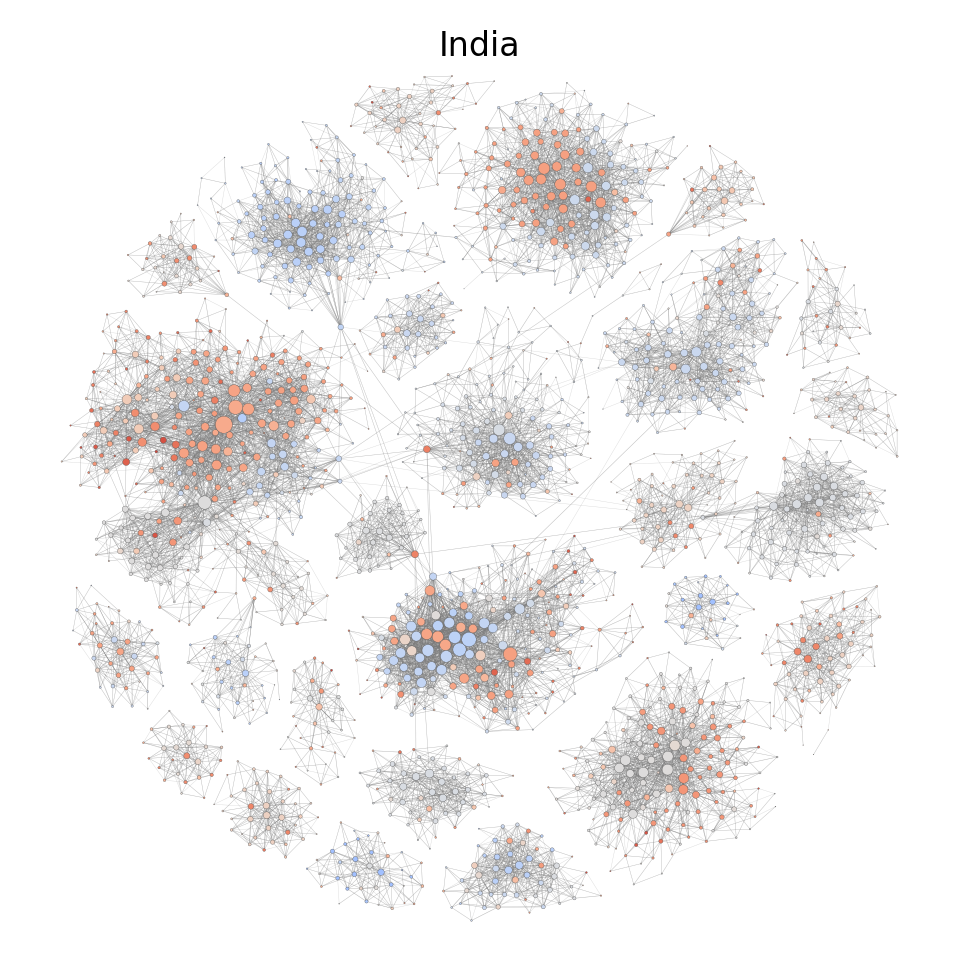

In [16]:
fig, ax = draw_netwulf(positions, figsize=3)

# Title at top left
fig.text(0.5, 1.02, f"{country.capitalize()}",
         fontsize=8, ha='center', va='top')

if country == 'mexico':
    legend_elements = [
        Line2D([0], [0],
            marker='o',
            color='none',
            label=f'{s:.1f}',
            lw=0,
            markeredgecolor='none',
            markeredgewidth=0,
            markerfacecolor=c,
            markersize=6)
        for s, c in legend_colors.items()
    ]

    ax.legend(
        handles=legend_elements,
        loc='lower left',
        bbox_to_anchor=(1.02, 0),  # shift to right outside, bottom aligned
        fontsize=6,
        frameon=False,
        title='Deprivation\nLevel',
        title_fontsize=6
    )

pl.savefig(f"../figures/{country}_graph.png", dpi=300, bbox_inches='tight')

## City figure

In [6]:
city_example, country = "New Delhi", 'india'    # "New Delhi", 'india' | 'Greater Mexico City', 'mexico'
# Get all nodes belonging to that city
city_nodes = [n for n, d in G1.nodes(data=True) if d.get('city') == city_example]

# Extract the subgraph
G_city = G1.subgraph(city_nodes).copy()

print(f"✅ Subgraph for {city_example}: {G_city.number_of_nodes()} nodes, {G_city.number_of_edges()} edges")

✅ Subgraph for New Delhi: 305 nodes, 5291 edges


In [119]:
city_example, country = 'Greater Mexico City', 'mexico'
# Get all nodes belonging to that city
city_nodes = [n for n, d in G2.nodes(data=True) if d.get('city') == city_example]

# Extract the subgraph
G_city = G2.subgraph(city_nodes).copy()

print(f"✅ Subgraph for {city_example}: {G_city.number_of_nodes()} nodes, {G_city.number_of_edges()} edges")

✅ Subgraph for Greater Mexico City: 513 nodes, 17325 edges


In [7]:
# Ensure you’re working on a copy (to preserve the original G2)
G_city = G_city.copy()

# For each node, get its centroid from the H3 index
for n, d in G_city.nodes(data=True):
    h = d.get("id", n)  # node ID is the H3 cell
    try:
        lat, lon = h3.cell_to_latlng(h)
        d["latitude"] = lat
        d["longitude"] = lon
        d["color"] = color_dict.get(n, "#cccccc")  # default gray if not found
    except Exception as e:
        print(f"⚠️ Skipped invalid H3 index {h}: {e}")

In [8]:
# Get the first node and its attributes
first_node = list(G_city.nodes(data=True))[0]
pprint(first_node)    

('873da1129ffffff',
 {'city': 'New Delhi',
  'color': '#c4d5f3',
  'deprivation': 13.286248,
  'label': '873da1129ffffff',
  'latitude': 28.62266395227332,
  'longitude': 77.10826649338914})


In [9]:
# Create GeoDataFrame of nodes
nodes_gdf = gpd.GeoDataFrame(
    {
        "node": list(G_city.nodes()),
        "color": [d.get("color", "#1f77b4") for _, d in G_city.nodes(data=True)]
    },
    geometry=gpd.points_from_xy(
        [d["longitude"] for _, d in G_city.nodes(data=True)],
        [d["latitude"] for _, d in G_city.nodes(data=True)]
    ),
    crs="EPSG:4326"
)

# Convert to Web Mercator projection
nodes_gdf = nodes_gdf.to_crs(epsg=3857)

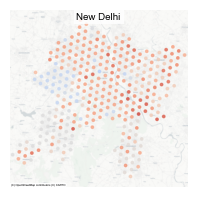

In [14]:
from matplotlib.cm import ScalarMappable

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots(figsize=(45/25.4, 45/25.4))

# fill entire canvas with axes
fig.subplots_adjust(0, 0, 1, 1)

ax.set_rasterization_zorder(0)

# -----------------
# square extent
# -----------------
xmin, ymin, xmax, ymax = nodes_gdf.total_bounds
cx, cy = (xmin + xmax)/2, (ymin + ymax)/2
half = max(xmax-xmin, ymax-ymin)/2 * 1.03

ax.set_xlim(cx-half, cx+half)
ax.set_ylim(cy-half, cy+half)
ax.set_aspect("equal")

# -----------------
# basemap
# -----------------
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12,
    attribution_size=2,
    zorder=0
)

# -----------------
# nodes
# -----------------
nodes_gdf.plot(
    ax=ax,
    color=nodes_gdf["color"],
    markersize=3,
    alpha=0.7,
    zorder=3
)

ax.axis("off")

# -----------------
# title INSIDE axes
# -----------------
ax.text(
    0.5, 0.985, city_example,
    transform=ax.transAxes,
    ha="center", va="top",
    bbox=dict(
        facecolor="white",
        alpha=0.8,        # transparency (0–1)
        edgecolor="none",
        pad=2
    )
)

# # -----------------
# # legend INSIDE axes (horizontal)
# # -----------------
# lg = True
# if lg:
#     legend_elements = [
#         Line2D([0], [0],
#                marker='o', color='none',
#                label=f'{s:.1f}',
#                markerfacecolor=c,
#                markeredgecolor='none',
#                markersize=4)
#         for s, c in legend_colors.items()
#     ]

#     ax.legend(
#         title='Deprivation level',
#         handles=legend_elements,
#         ncol=len(legend_elements),
#         loc="upper center",
#         bbox_to_anchor=(0.5, 1.2),  # inside axes!
#         frameon=False,
#         columnspacing=0.7,
#         handletextpad=0.3
#     )

# -----------------
# continuous colorbar ABOVE the figure
# -----------------
lg = False
if lg:

    # create a new axis above the main axes
    cax = fig.add_axes([0.2, 0.92, 0.6, 0.02])  
    # [left, bottom, width, height] in figure coordinates

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cbar.set_label("Deprivation level")

    # quantile ticks
    cbar.set_ticks(deprivation_samples)
    cbar.set_ticklabels([f"{v:.1f}" for v in deprivation_samples])

# -----------------
# save (NO tight bbox!)
# -----------------
fig.savefig(
    f"../figures/{city_example}_lg.pdf",
    dpi=600,
    facecolor="white"
)

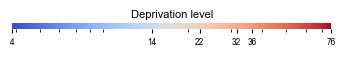

In [27]:
fig = plt.figure(figsize=(90/25.4, 4/25.4))  # 90 mm wide

# create colorbar axis
cax = fig.add_axes([0.05, 0.35, 0.9, 0.35])

# mappable
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# draw colorbar
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

# quantile ticks
cbar.set_ticks(deprivation_samples)
cbar.set_ticklabels([f"{v:.0f}" for v in deprivation_samples])

# move label ABOVE
cbar.ax.xaxis.set_label_position('top')
cbar.set_label("Deprivation level", labelpad=4)
# remove border
cbar.outline.set_visible(False)
# style
cbar.ax.tick_params(length=3)
cbar.outline.set_linewidth(0.4)

# save
fig.savefig(
    "../figures/deprivation_colorbar.pdf",
    dpi=600,
    facecolor="white"
)

## City graph
### India

In [62]:
country, city_example = 'india', 'New Delhi'    # "New Delhi", 'india' | 'Greater Mexico City'
# Get all nodes belonging to that city
city_nodes = [n for n, d in G1.nodes(data=True) if d.get('city') == city_example]
# Get the first node and its attributes
G1_city = G1.copy()
# Keep only edges whose source is in city_nodes
edges_to_keep = [(u, v) for u, v in G1.edges() if u in city_nodes]
G1_city = G1_city.edge_subgraph(edges_to_keep).copy()

print(f"Original edges: {G1.number_of_edges()}, Filtered edges: {G1_city.number_of_edges()}")

Original edges: 27047, Filtered edges: 5303


In [63]:
positions, b = nu.visualize(G1_city)

c:\Users\yuanlia\AppData\Local\miniconda3\envs\labstack\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [64]:
# Save to file
with open(f'../data/positions_and_b_{country}_city.pkl', 'wb') as f:
    pickle.dump((positions, b), f)

In [65]:
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

100%|██████████| 313/313 [00:00<?, ?it/s]


In [ ]:
country = 'india' # mexico, india
with open(f'../data/network_viz/positions_and_b_{country}_city.pkl', 'rb') as f:
    positions, b = pickle.load(f)
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

100%|██████████| 1957/1957 [00:00<00:00, 778845.52it/s]


C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20040\2409609485.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


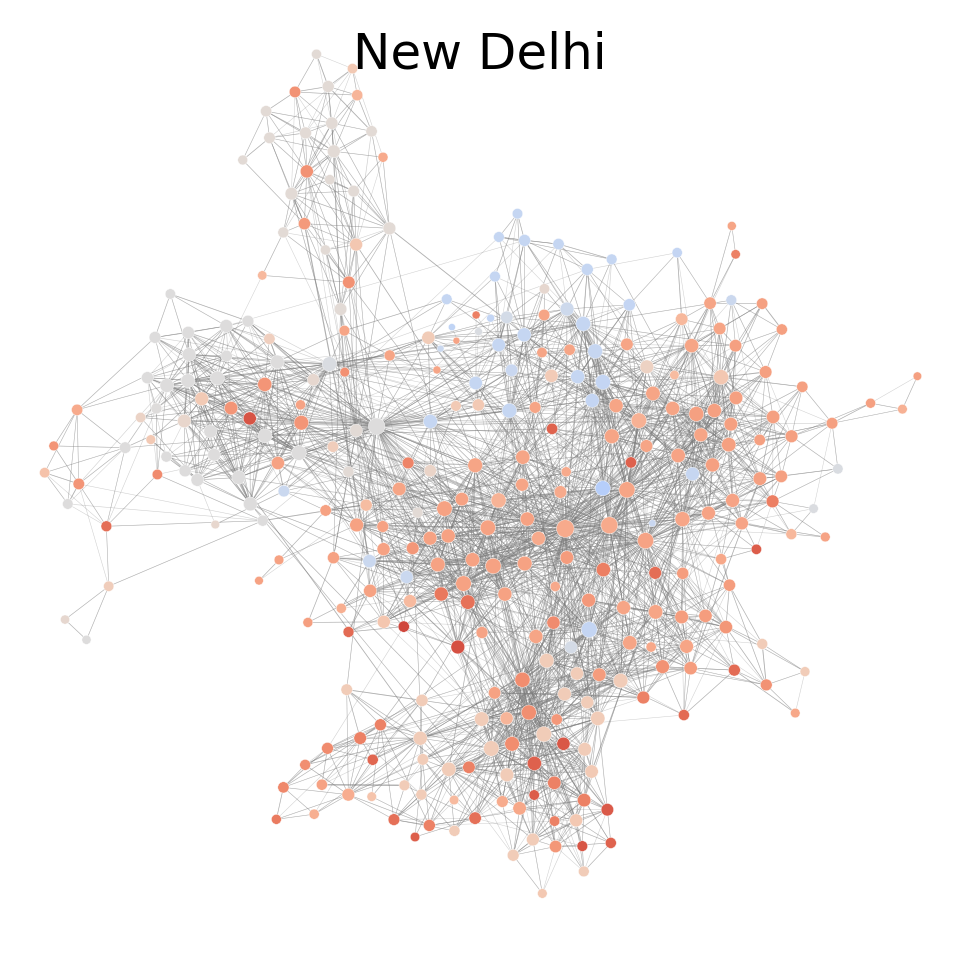

In [66]:
fig, ax = draw_netwulf(positions, figsize=3)

# Title at top left
fig.text(0.5, 1.02, f"{city_example}",
         fontsize=12, ha='center', va='top')
fig.savefig(
    f"../figures/{city_example}_{country}_graph.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

### Mexico

In [53]:
country, city_example = 'mexico', 'Greater Mexico City'    # "New Delhi", 'india' | 'Greater Mexico City'
# Get all nodes belonging to that city
city_nodes = [n for n, d in G2.nodes(data=True) if d.get('city') == city_example]
# Get the first node and its attributes
G2_city = G2.copy()
# Keep only edges whose source is in city_nodes
edges_to_keep = [(u, v) for u, v in G2.edges() if u in city_nodes]
G2_city = G2_city.edge_subgraph(edges_to_keep).copy()

print(f"Original edges: {G2.number_of_edges()}, Filtered edges: {G2_city.number_of_edges()}")

Original edges: 54355, Filtered edges: 17457


In [ ]:
# Save to file
positions, b = nu.visualize(G2_city)
with open(f'../data/network_viz/positions_and_b_{country}_city.pkl', 'wb') as f:
    pickle.dump((positions, b), f)
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

c:\Users\yuanlia\AppData\Local\miniconda3\envs\labstack\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
100%|██████████| 589/589 [00:00<00:00, 408946.38it/s]


In [ ]:
country = 'mexico' # mexico, india
with open(f'../data/network_viz/positions_and_b_{country}_city.pkl', 'rb') as f:
    positions, b = pickle.load(f)
for node in tqdm(positions['nodes']):
    node['color'] = color_dict[node['id']]

100%|██████████| 2601/2601 [00:00<00:00, 577460.55it/s]


C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20040\2409609485.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


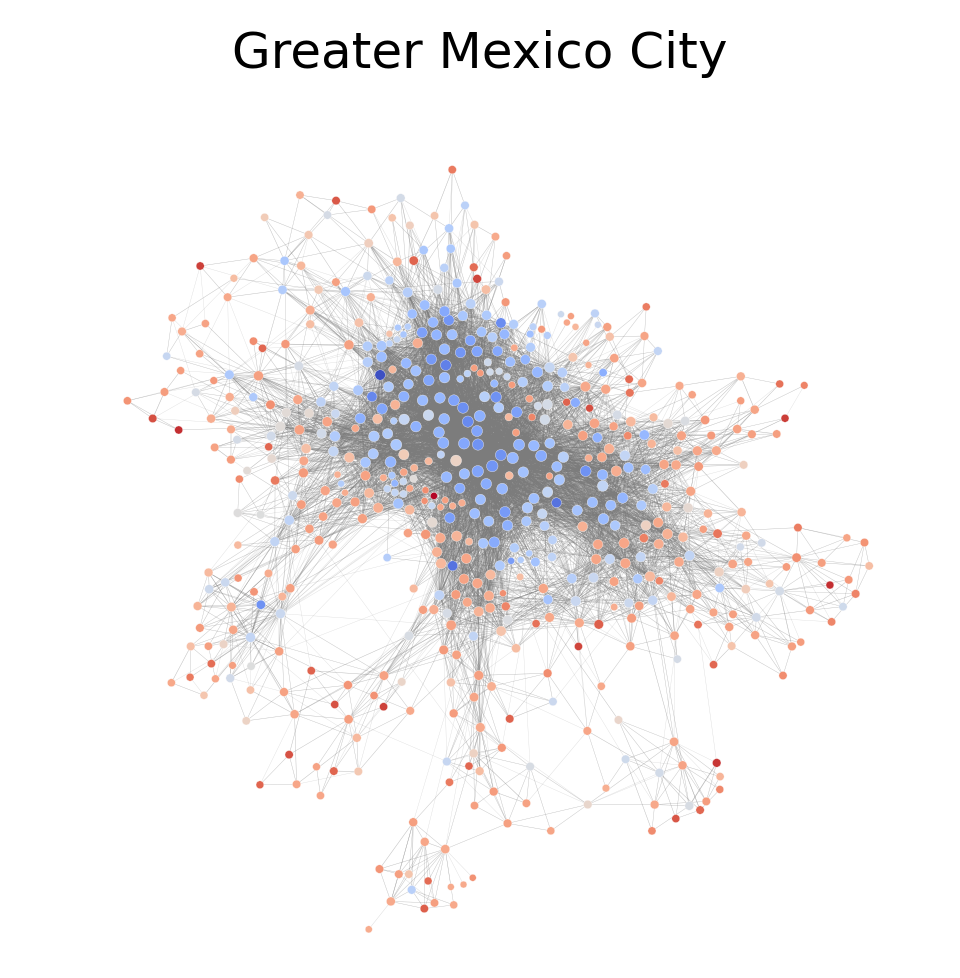

In [61]:
fig, ax = draw_netwulf(positions, figsize=3)

# Title at top left
fig.text(0.5, 1.02, f"{city_example}",
         fontsize=12, ha='center', va='top')

# if country == 'mexico':
#     legend_elements = [
#         Line2D([0], [0],
#             marker='o',
#             color='none',
#             label=f'{s:.1f}',
#             lw=0,
#             markeredgecolor='none',
#             markeredgewidth=0,
#             markerfacecolor=c,
#             markersize=6)
#         for s, c in legend_colors.items()
#     ]

#     ax.legend(
#         handles=legend_elements,
#         loc='lower left',
#         bbox_to_anchor=(1.02, 0),  # shift to right outside, bottom aligned
#         fontsize=10,
#         frameon=False,
#         title='Deprivation\nLevel',
#         title_fontsize=10
#     )
# --- save as SVG (vector) ---
fig.savefig(
    f"../figures/{city_example}_{country}_graph.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)
# pl.savefig(f"../figures/{city_example}_{country}_graph.png", dpi=300, bbox_inches='tight')